# Support Vector Machines

- can perform linear or non-linear classification
- works on small-to-medium datasets well, but don't scale to very large datasets

- `large margin classification` is when two class instances are far away from each other 

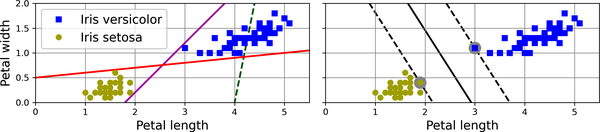

- when using SVM, it is better to have wide street between two decision boundaries is better 
- because if street is too small, later if outliers overlap with opposite class instances, model crashes 
- sometimes `StandartScaler` helps to widen the space between two decision boundaries of instances

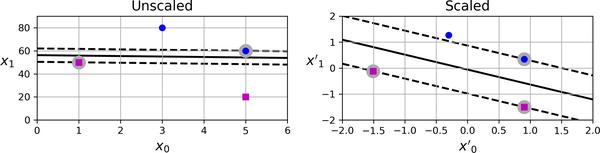

- SVM model complexity can be controller using the hyperpparameters such as `C`
- If model is overfitting we reduce the value of `C`, otherwise increase
- First image shows overfitted model and second with `C=100` showing decent generalization

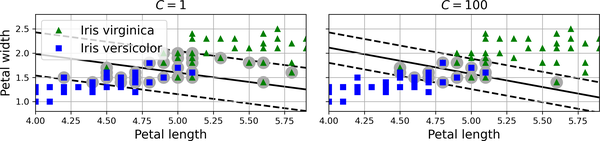

## Linear SVM

In [4]:
from sklearn.datasets import load_iris
from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

iris = load_iris(as_frame=True)

X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = (iris.target == 2)  # Iris virginica




array([False,  True])

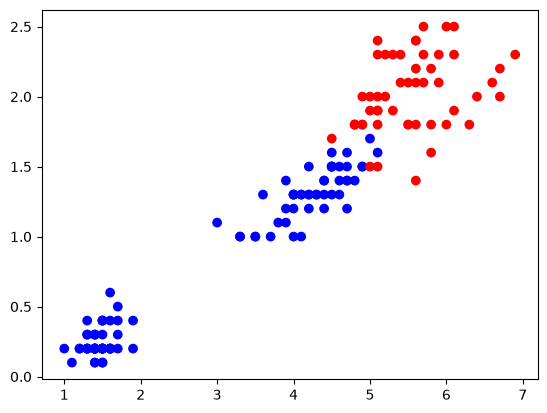

In [7]:
import matplotlib.pyplot as plt

# Convert Booleans to 1s and 0s
colors = [int(val) for val in y]

plt.scatter(X[:, 0], X[:, 1], c=colors, cmap="bwr", vmin=0, vmax=1)

In [22]:


svm_clf = make_pipeline(
    StandardScaler(),
    LinearSVC(C=100, random_state=42)
)   
svm_clf.fit(X, y)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('linearsvc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[bool](2,)","[False, True]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,2
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [23]:
X_new = [[5.5, 1.7], [5.0, 1.5]]
svm_clf.predict(X_new)

array([ True, False])

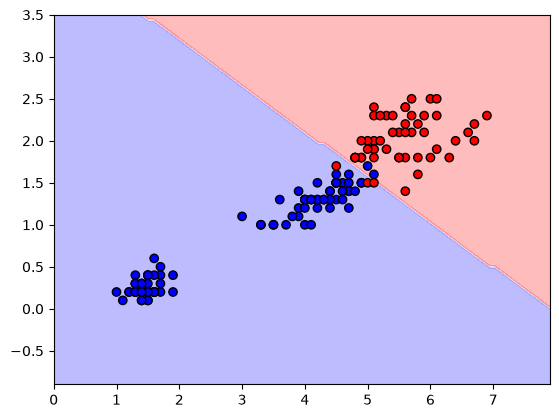

In [24]:
from sklearn.inspection import DecisionBoundaryDisplay

DecisionBoundaryDisplay.from_estimator(
    svm_clf, X, response_method="predict", cmap="bwr", alpha=0.3
)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolors="k")
plt.show()

In [12]:
svm_clf.decision_function(X_new)

array([ 1.27064191, -0.22916017])

## Non-Linear SVM Classification

- many datasets are not even close to being linearly separable: add polynomial features to make linearly separable dataset

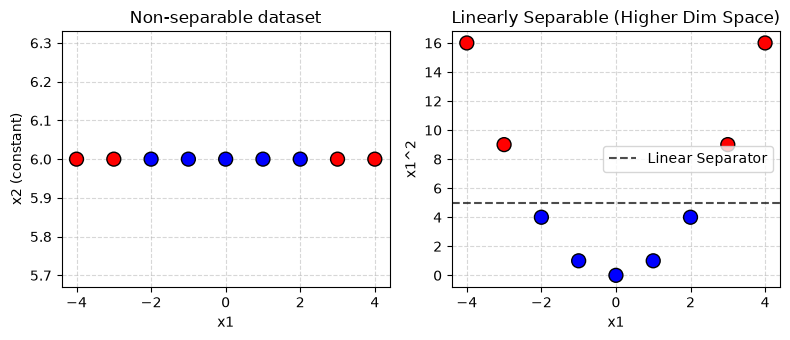

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures

# 1. Create the DataFrame
df = pd.DataFrame({
   "x1": np.arange(-4, 5),
   "x2": [6] * 9,
   "y": (np.abs(np.arange(-4, 5)) > 2)
})

# FIX 1: Reference df["y"] correctly to build the color mapping array
colors = [int(val) for val in df["y"]]

# 2. Setup the side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3.5))

# Plot 1: Original non-separable 1D/2D dataset
ax1.scatter(df["x1"], df["x2"], c=colors, cmap="bwr", s=100, edgecolors='k', zorder=3)
ax1.set_title("Non-separable dataset")
ax1.set_xlabel("x1")
ax1.set_ylabel("x2 (constant)")
ax1.grid(True, linestyle="--", alpha=0.5)

# 3. Apply polynomial transformation (degree=2 by default)
poly = PolynomialFeatures()
pol_df = poly.fit_transform(df[["x1", "x2"]])

# FIX 2: Dynamic feature mapping for plotting
# pol_df[:, 1] corresponds to 'x1'
# pol_df[:, 3] corresponds to 'x1^2'
x1_transformed = pol_df[:, 1]
x1_squared = pol_df[:, 3]

# Plot 2: Project data into higher-dimensional space where it's separable
ax2.scatter(x1_transformed, x1_squared, c=colors, cmap="bwr", s=100, edgecolors='k', zorder=3)

# Draw a visual linear decision boundary line showing complete separation
ax2.axhline(y=5, color="black", linestyle="--", alpha=0.7, label="Linear Separator")

ax2.set_title("Linearly Separable (Higher Dim Space)")
ax2.set_xlabel("x1")
ax2.set_ylabel("x1^2")
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend()

plt.tight_layout()
plt.show()


- seen from thhe plots, if we use correclt ploynomial features we can make dataset linearly separable which enables us to use `LinearSVC` model to fit it

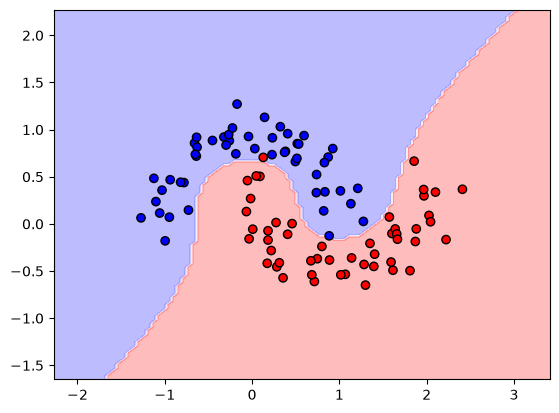

In [40]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import PolynomialFeatures

X, y = make_moons(n_samples=100, noise=0.15, random_state=42)

polynomial_svm_clf = make_pipeline(
    PolynomialFeatures(degree=3),
    StandardScaler(),
    LinearSVC(C=10, max_iter=10_000, random_state=42)
)
polynomial_svm_clf.fit(X, y)

from sklearn.inspection import DecisionBoundaryDisplay

DecisionBoundaryDisplay.from_estimator(
    polynomial_svm_clf, X, response_method="predict", cmap="bwr", alpha=0.3
)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolors="k")
plt.show()

In [ ]:
from sklearn.svm import SVC

poly_kernel_svm_clf = make_pipeline(StandardScaler(),
                                    SVC(kernel="poly", degree=3, coef0=1, C=5))
poly_kernel_svm_clf.fit(X, y)

poly_kernel_svm_clf2 = make_pipeline(StandardScaler(),
                                    SVC(kernel="poly", degree=3, coef0=100, C=5))
poly_kernel_svm_clf2.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('svc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,2
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


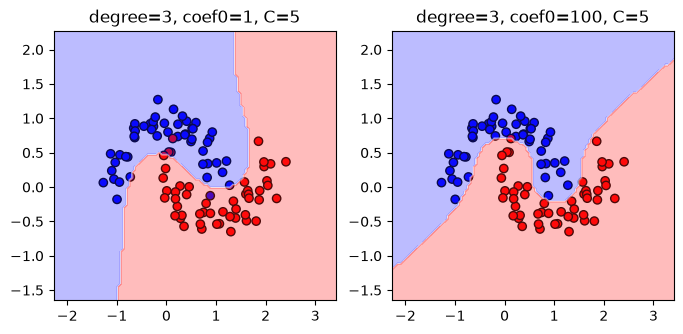

In [52]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3.5))

ax1.set_title("degree=3, coef0=1, C=5")
ax2.set_title("degree=3, coef0=100, C=5")

ax1.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolors="k")
ax2.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolors="k")

DecisionBoundaryDisplay.from_estimator(
    poly_kernel_svm_clf, X, response_method="predict", cmap="bwr", alpha=0.3,
    ax=ax1
)
DecisionBoundaryDisplay.from_estimator(
    poly_kernel_svm_clf2, X, response_method="predict", cmap="bwr", alpha=0.3,
    ax=ax2
)


## Gaussian RBF Kernel

- Like in `PolynomialFeatures` RBF kernel algorithm makes new features using pairs of each original features of training set
- As a result, the number of features will be equal to the number of all samples. 
- To avoid problems with large training sets, using cross-validation is important because the number of samples will be reduced as they split into folds, reducing  the number of rbf-generated features 
- there are two main hyperparameters of the `SVC(kernel='rbf')`: in `C` changes the margin width to increase the accuracy by exluding samlples out of the street while the `γ` (gamma) tries to fit model based on each indivial samples making the decision boundary more wavy and complex
- both of hypermarametrs can result in underfitting and overfitting, thus tuning should be done carefully

## Choosing right SVM model

- first always try a `LinearSVC` after making dataset linearrly separable because it is the fastest approach to experiment
- don't use `SVC(kernel='linear')` instead use `LinearSVC`
- while tuning try to use optimized hp ranges
- then we can try different alogrithms 

## Computational Complexity

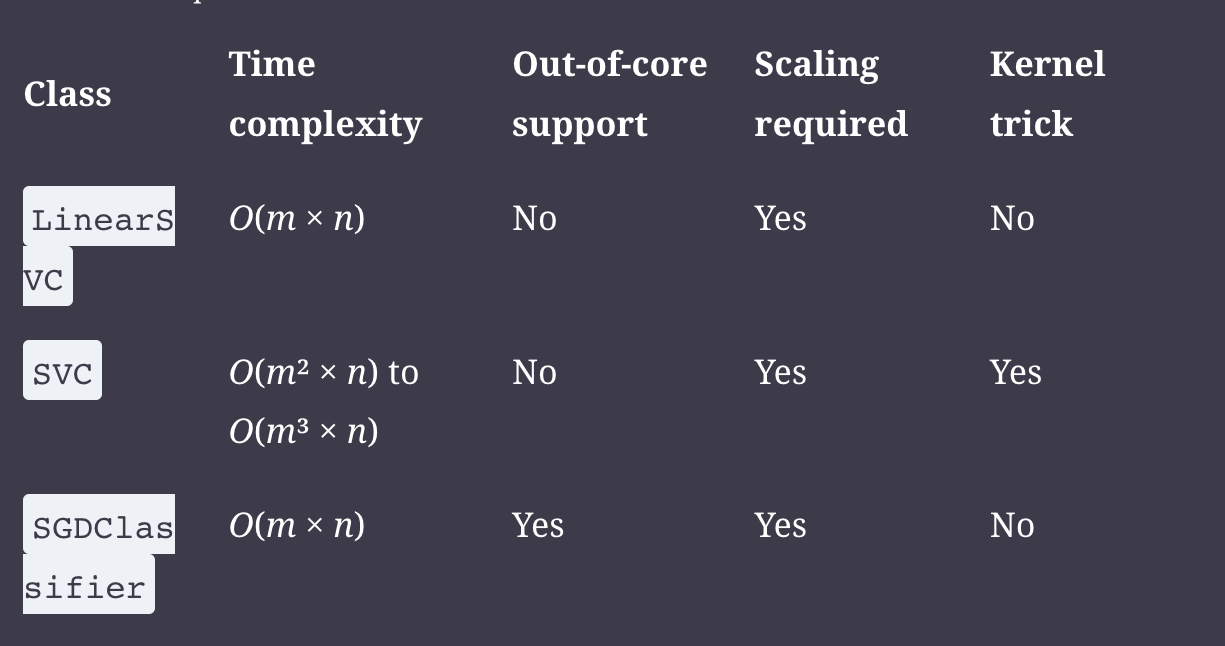